# 8. Visualise PyNNLF Output: SA BESS 44hh Clean Cohort

Databricks full-run version. This notebook visualises the processed CSVs produced from the complete `experiment_result_databricks` run.


## 1. Setup And Paths

In [1]:
from pathlib import Path
import sys


def find_publication_project(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "specs").exists() and (candidate / "data").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find publication/journal_article_1 from the current working directory.")


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "pynnlf").exists():
            return candidate
    raise FileNotFoundError("Could not find the PyNNLF repo root.")


PROJECT_DIR = find_publication_project()
REPO_ROOT = find_repo_root(PROJECT_DIR)
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results" / "04_sa_bess_clean_44hh"
FIGURES_DIR = RESULTS_DIR / "figures"
EXPERIMENT_SOURCE_DIR = PROJECT_DIR / "experiment_result_databricks"
RESULT_SOURCE_LABEL = "Databricks complete run"

print(f"Publication project: {PROJECT_DIR}")
print(f"Repository root: {REPO_ROOT}")
print(f"Experiment source: {EXPERIMENT_SOURCE_DIR}")
print(f"Result source: {RESULT_SOURCE_LABEL}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


Publication project: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1
Repository root: C:\Users\z5404477\Documents\PyNNLF
Experiment source: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\experiment_result_databricks
Result source: Databricks complete run


## 2. Constants And Helper Functions

In [2]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SPECS = {
    "underlying_load": {
        "dataset_no": "ds22",
        "filename": "ds22_sa_bess_44hh_pos_underlying_load_30min.csv",
        "label": "Underlying load",
    },
    "net_load_with_pv": {
        "dataset_no": "ds23",
        "filename": "ds23_sa_bess_44hh_pos_net_load_with_pv_30min.csv",
        "label": "Net load with PV",
    },
    "net_load_with_pv_battery": {
        "dataset_no": "ds24",
        "filename": "ds24_sa_bess_44hh_pos_net_load_with_pv_battery_30min.csv",
        "label": "Net load with PV and battery",
    },
}
DATASET_ORDER = ["underlying_load", "net_load_with_pv", "net_load_with_pv_battery"]
DATASET_LABELS = {key: spec["label"] for key, spec in DATASET_SPECS.items()}
DATASET_NO_TO_KEY = {spec["dataset_no"]: key for key, spec in DATASET_SPECS.items()}

MODEL_ORDER = [
    "m1_naive_hp1",
    "m2_snaive_hp2",
    "m3_ets_hp1",
    "m4_arima_hp1",
    "m6_lr_hp1",
    "m7_ann_hp1",
    "m8_dnn_hp1",
    "m9_rt_hp3",
    "m10_rf_hp1",
    "m13_lstm_hp2",
    "m16_prophet_hp1",
    "m17_xgb_hp1",
]

COLORS = {
    "underlying_load": "#1f77b4",
    "net_load_with_pv": "#2ca02c",
    "net_load_with_pv_battery": "#d62728",
}

EXPECTED_ROWS = 17_520
EXPECTED_FREQ = pd.Timedelta(minutes=30)
FH8_MINUTES = 1440


def save_figure(fig, filename: str) -> Path:
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")
    return path


print(f"Figures output: {FIGURES_DIR}")
print(f"Expected datasets: {[spec['dataset_no'] for spec in DATASET_SPECS.values()]}")


Figures output: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures
Expected datasets: ['ds22', 'ds23', 'ds24']


## 3. Load Datasets

In [3]:
def validate_dataset_frame(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    required_columns = {"datetime", "netload_kW"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing_columns)}")

    frame = df[["datetime", "netload_kW"]].copy()
    if frame["datetime"].isna().any():
        raise ValueError(f"{path.name} contains missing datetime values")
    if frame["datetime"].duplicated().any():
        duplicates = int(frame["datetime"].duplicated().sum())
        raise ValueError(f"{path.name} contains {duplicates} duplicate timestamps")
    if frame["netload_kW"].isna().any():
        missing_count = int(frame["netload_kW"].isna().sum())
        raise ValueError(f"{path.name} contains {missing_count} missing netload_kW values")

    frame = frame.sort_values("datetime").reset_index(drop=True)
    if len(frame) != EXPECTED_ROWS:
        raise ValueError(f"{path.name} expected {EXPECTED_ROWS:,} rows, found {len(frame):,}")
    diffs = frame["datetime"].diff().dropna()
    bad_diffs = diffs.loc[diffs.ne(EXPECTED_FREQ)]
    if not bad_diffs.empty:
        raise ValueError(f"{path.name} is not consistently spaced at 30 minutes")
    return frame


series = []
dataset_validation = []
for key, spec in DATASET_SPECS.items():
    path = DATA_DIR / spec["filename"]
    if not path.exists():
        raise FileNotFoundError(f"Missing dataset {path}. Run notebook 5 first.")
    df = pd.read_csv(path, parse_dates=["datetime"])
    df = validate_dataset_frame(df, path)
    series.append(df.rename(columns={"netload_kW": key}))
    dataset_validation.append(
        {
            "dataset_no": spec["dataset_no"],
            "label": spec["label"],
            "rows": len(df),
            "start": df["datetime"].min(),
            "end": df["datetime"].max(),
            "missing_netload_kW": int(df["netload_kW"].isna().sum()),
            "duplicate_timestamps": int(df["datetime"].duplicated().sum()),
        }
    )

datasets = series[0]
for frame in series[1:]:
    datasets = datasets.merge(frame, on="datetime", how="inner")
if datasets.shape[0] != EXPECTED_ROWS:
    raise ValueError(f"Merged dataset expected {EXPECTED_ROWS:,} rows, found {datasets.shape[0]:,}")

display(pd.DataFrame(dataset_validation))
display(datasets.head())

,dataset_no,label,rows,start,end,missing_netload_kW,duplicate_timestamps
0,ds22,Underlying load,17520,2024-02-26,2025-02-24 23:30:00,0,0
1,ds23,Net load with PV,17520,2024-02-26,2025-02-24 23:30:00,0,0
2,ds24,Net load with PV and battery,17520,2024-02-26,2025-02-24 23:30:00,0,0


,datetime,underlying_load,net_load_with_pv,net_load_with_pv_battery
0,2024-02-26 00:00:00,31.736383,31.945081,21.285537
1,2024-02-26 00:30:00,30.660720,30.868053,20.859843
2,2024-02-26 01:00:00,28.529513,28.741316,20.851976
3,2024-02-26 01:30:00,29.422615,29.635479,20.921186
4,2024-02-26 02:00:00,28.169503,28.379177,20.635719


## 4. Dataset Profiles And Distributions

,mean,std,min,median,max
Underlying load,48.190,17.094,18.350,46.795,137.520
Net load with PV,-10.829,68.526,-214.177,25.977,101.367
Net load with PV and battery,-8.460,52.836,-199.757,16.244,71.734


Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig01_dataset_distributions.png


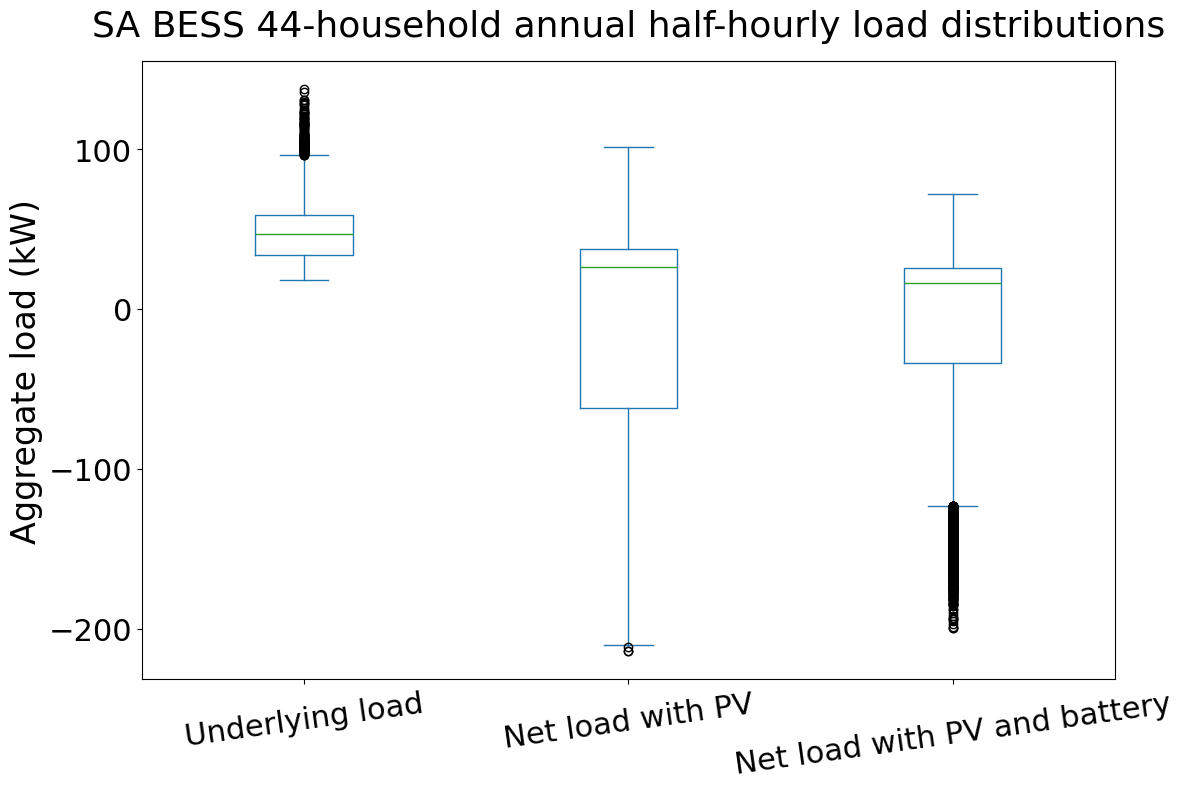

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig02_typical_week_profile.png


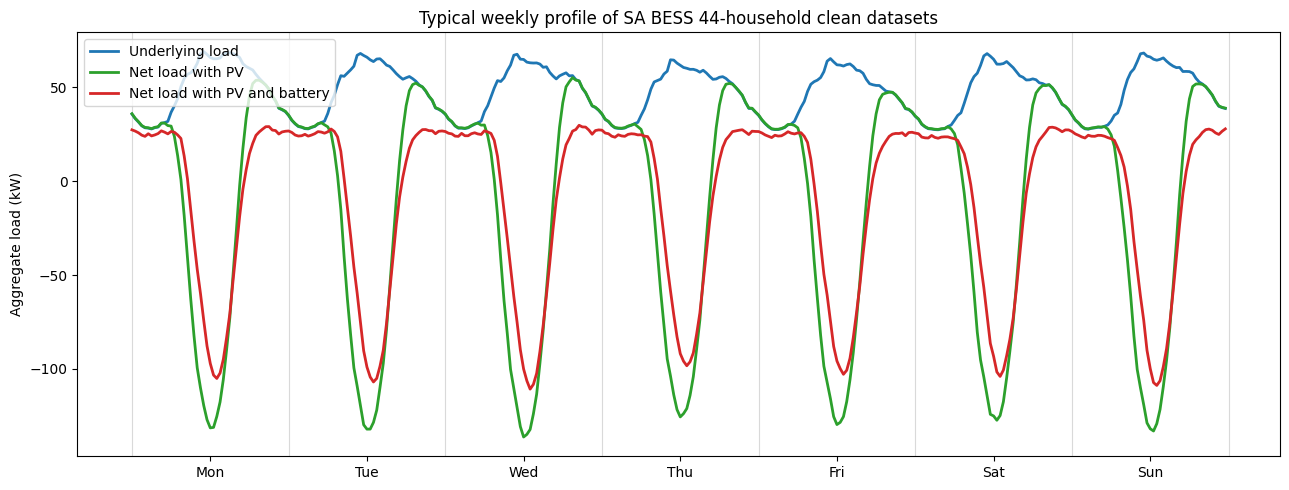

In [4]:
summary_stats = datasets[DATASET_ORDER].agg(["mean", "std", "min", "median", "max"]).T.rename(index=DATASET_LABELS).round(3)
display(summary_stats)
fig, ax = plt.subplots(figsize=(12, 8))
datasets[DATASET_ORDER].rename(columns=DATASET_LABELS).plot.box(ax=ax)
ax.set_ylabel("Aggregate load (kW)", fontsize=24)
ax.set_title("SA BESS 44-household annual half-hourly load distributions", fontsize=26, pad=18)
ax.tick_params(axis="x", rotation=8, labelsize=22)
ax.tick_params(axis="y", labelsize=22)
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
fig.tight_layout()
save_figure(fig, "fig01_dataset_distributions.png")
plt.show()
profile_source = datasets.copy()
profile_source["week_slot"] = profile_source["datetime"].dt.dayofweek * 48 + profile_source["datetime"].dt.hour * 2 + profile_source["datetime"].dt.minute // 30
typical_week = profile_source.groupby("week_slot")[DATASET_ORDER].mean().reindex(range(7 * 48))
fig, ax = plt.subplots(figsize=(13, 5))
for dataset_key in DATASET_ORDER:
    ax.plot(typical_week.index, typical_week[dataset_key], label=DATASET_LABELS[dataset_key], color=COLORS[dataset_key], linewidth=2.0)
for day in range(8):
    ax.axvline(day * 48, color="0.85", linewidth=0.8, zorder=0)
ax.set_xticks([day * 48 + 24 for day in range(7)])
ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_ylabel("Aggregate load (kW)")
ax.set_title("Typical weekly profile of SA BESS 44-household clean datasets")
ax.legend(loc="upper left")
fig.tight_layout()
save_figure(fig, "fig02_typical_week_profile.png")
plt.show()

## 5. Load Databricks-Complete PyNNLF Result Tables

In [5]:
def validate_metric_table(table: pd.DataFrame, table_name: str) -> pd.DataFrame:
    table.index = table.index.astype(str)
    missing_models = [model for model in MODEL_ORDER if model not in table.index]
    missing_columns = [column for column in DATASET_ORDER if column not in table.columns]
    if missing_models or missing_columns:
        raise ValueError(
            f"{table_name} failed validation. "
            f"Missing models: {missing_models}; missing columns: {missing_columns}"
        )
    table = table.loc[MODEL_ORDER, DATASET_ORDER].apply(pd.to_numeric, errors="coerce")
    if table.isna().any().any():
        missing_cells = table.isna().stack().loc[lambda s: s].index.tolist()
        raise ValueError(f"{table_name} contains missing/non-numeric cells: {missing_cells[:10]}")
    return table


result_files = {
    "nrmse": RESULTS_DIR / "sa_bess_44hh_fh8_nrmse_comparison.csv",
    "stddev": RESULTS_DIR / "sa_bess_44hh_fh8_nrmse_stddev_comparison.csv",
}
missing = [str(path) for path in result_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing processed PyNNLF result files. Run notebook 7 after the Databricks complete experiments. " + str(missing))

nrmse = validate_metric_table(pd.read_csv(result_files["nrmse"], index_col=0), "nRMSE result table")
stddev = validate_metric_table(pd.read_csv(result_files["stddev"], index_col=0), "nRMSE stddev result table")

recap_path = EXPERIMENT_SOURCE_DIR / "a1_experiment_result.csv"
if recap_path.exists():
    recap = pd.read_csv(recap_path)
    expected_pairs = {(spec["dataset_no"], model) for spec in DATASET_SPECS.values() for model in MODEL_ORDER}
    recap_subset = recap.loc[
        recap["dataset_no"].astype(str).isin(DATASET_NO_TO_KEY)
        & pd.to_numeric(recap["forecast_horizon_min"], errors="coerce").eq(FH8_MINUTES)
    ].copy()
    actual_pairs = set(zip(recap_subset["dataset_no"].astype(str), recap_subset["model_name"].astype(str)))
    duplicate_pairs = recap_subset.duplicated(["dataset_no", "model_name"], keep=False)
    print(f"Databricks recap rows for SA BESS fh8: {len(recap_subset)} / {len(expected_pairs)} expected successful combinations")
    if expected_pairs - actual_pairs:
        print(f"Missing recap combinations: {sorted(expected_pairs - actual_pairs)}")
    if duplicate_pairs.any():
        display(recap_subset.loc[duplicate_pairs, ["experiment_folder", "dataset_no", "model_name"]])
    recap_folders = set(recap_subset.get("experiment_folder", pd.Series(dtype=str)).dropna().astype(str))
    experiment_folders = {path.name for path in EXPERIMENT_SOURCE_DIR.iterdir() if path.is_dir()}
    extra_folders = sorted(experiment_folders - recap_folders)
    if extra_folders:
        print("Extra experiment folders not used by the recap/results tables:")
        for folder in extra_folders:
            print(f"  - {folder}")
else:
    print(f"Recap file not found at {recap_path}; skipping Databricks folder diagnostic.")

display(nrmse.round(3))

Databricks recap rows for SA BESS fh8: 36 / 36 expected successful combinations
Extra experiment folders not used by the recap/results tables:
  - E00022_260526_ds23_fh1440_m13_lstm_hp2
  - E00035_260527_ds24_fh1440_m13_lstm_hp2


,underlying_load,net_load_with_pv,net_load_with_pv_battery
model_hp,,,
m1_naive_hp1,5.698,16.792,21.236
m2_snaive_hp2,6.692,21.371,27.709
m3_ets_hp1,5.580,16.925,21.298
m4_arima_hp1,10.471,51.458,57.678
m6_lr_hp1,4.786,14.761,18.947
m7_ann_hp1,5.459,15.339,19.595
m8_dnn_hp1,5.267,15.518,19.852
m9_rt_hp3,7.017,21.645,28.096
m10_rf_hp1,5.223,17.390,21.674


## 6. Model Performance Figures

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig03_model_performance_by_dataset.png


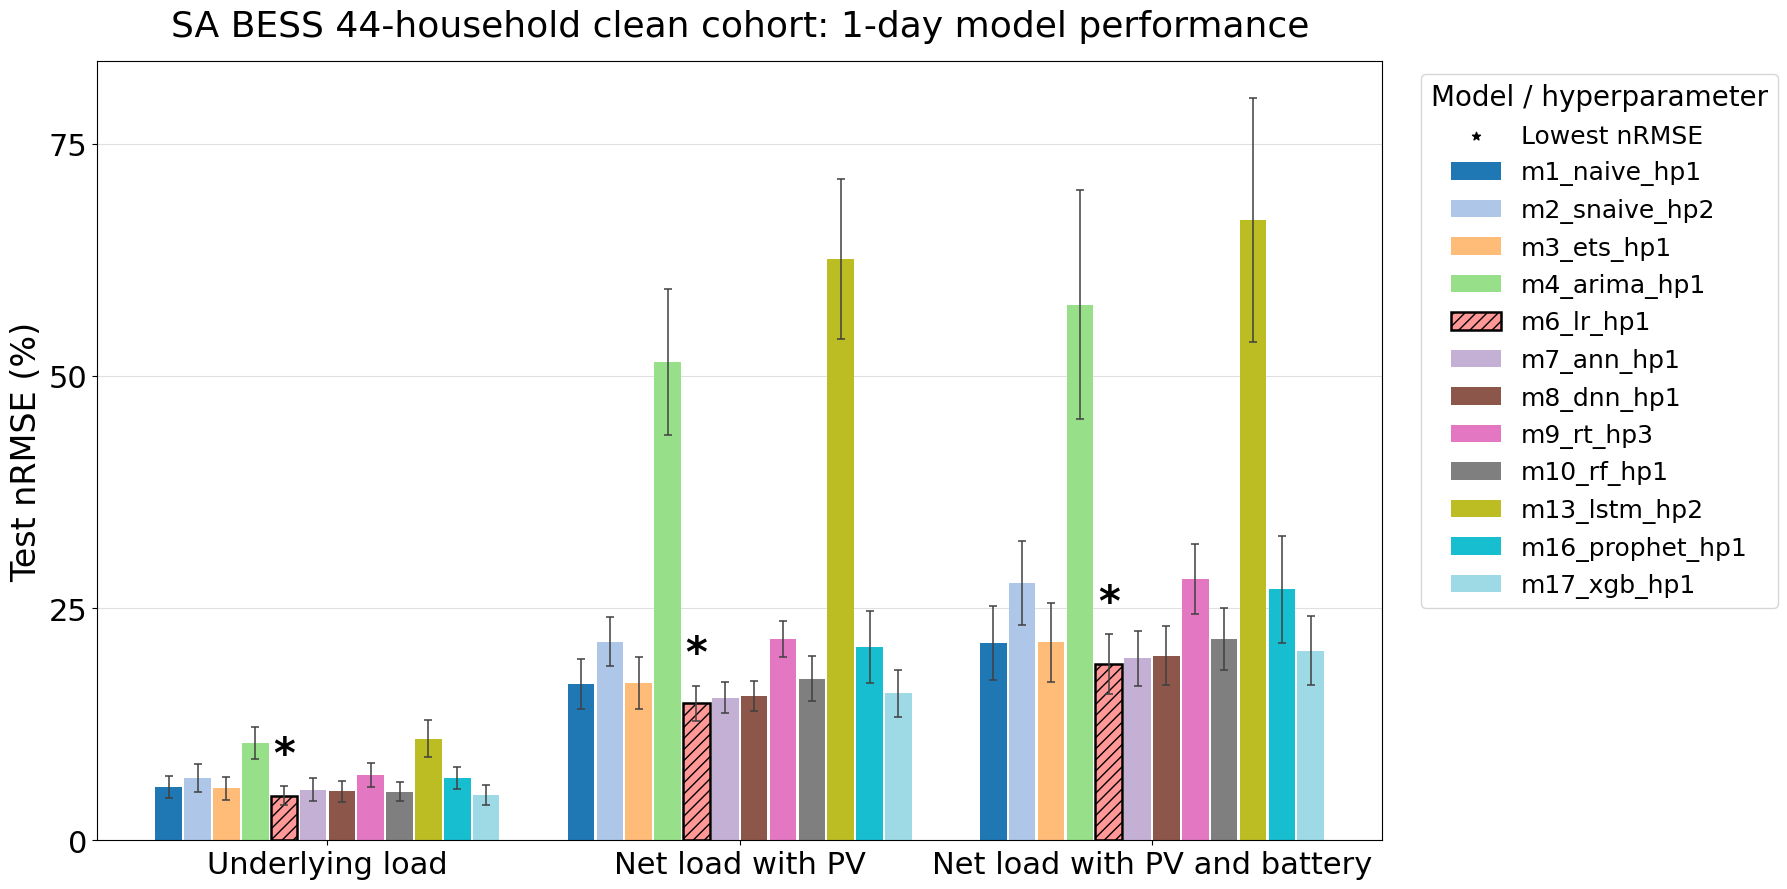

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig04_model_stability_stddev_by_dataset.png


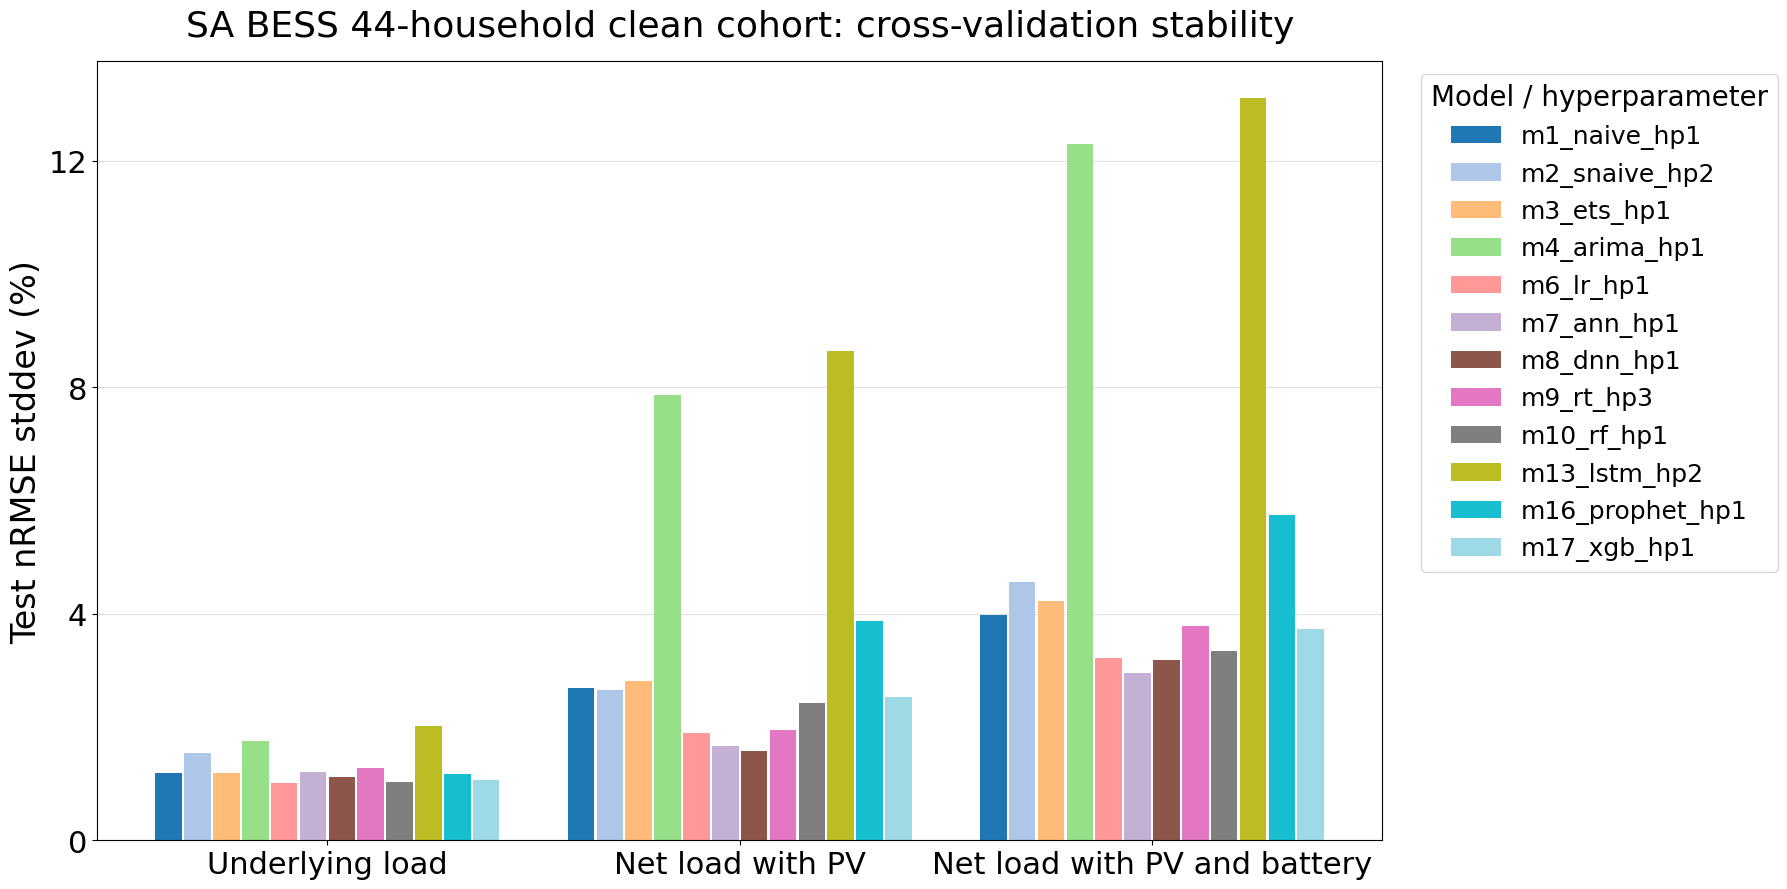

In [6]:
def plot_grouped_model_bars(
    metric_table: pd.DataFrame,
    *,
    ylabel: str,
    title: str,
    filename: str,
    yerr_table: pd.DataFrame | None = None,
    highlight_lowest: bool = False,
) -> None:
    x = np.arange(len(DATASET_ORDER))
    total_width = 0.84
    bar_width = total_width / len(MODEL_ORDER)
    colors = plt.cm.tab20(np.linspace(0, 1, len(MODEL_ORDER)))
    best_by_dataset = metric_table.idxmin(axis=0).to_dict() if highlight_lowest else {}

    fig, ax = plt.subplots(figsize=(18, 9))
    for model_idx, model in enumerate(MODEL_ORDER):
        offsets = x - total_width / 2 + bar_width / 2 + model_idx * bar_width
        heights = metric_table.loc[model, DATASET_ORDER].to_numpy(dtype=float)
        yerr = None if yerr_table is None else yerr_table.loc[model, DATASET_ORDER].to_numpy(dtype=float)
        bars = ax.bar(
            offsets,
            heights,
            width=bar_width * 0.92,
            label=model,
            color=colors[model_idx],
            yerr=yerr,
            capsize=3 if yerr is not None else 0,
            error_kw={"elinewidth": 1.1, "ecolor": "0.25", "capthick": 1.1},
        )
        if highlight_lowest:
            for dataset_idx, dataset_key in enumerate(DATASET_ORDER):
                if best_by_dataset.get(dataset_key) != model:
                    continue
                bar = bars[dataset_idx]
                bar.set_edgecolor("black")
                bar.set_linewidth(1.8)
                bar.set_hatch("///")
                error_padding = 0 if yerr is None else yerr[dataset_idx]
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    heights[dataset_idx] + error_padding + 1.1,
                    "*",
                    ha="center",
                    va="bottom",
                    fontsize=30,
                    fontweight="bold",
                    color="black",
                )

    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[key] for key in DATASET_ORDER], rotation=0, fontsize=22)
    ax.tick_params(axis="y", labelsize=22)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_ylabel(ylabel, fontsize=24)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=26, pad=18)
    ax.grid(axis="y", color="0.88", linewidth=0.8)
    ax.set_axisbelow(True)
    if highlight_lowest:
        ax.scatter([], [], marker="*", color="black", label="Lowest nRMSE")
    ax.legend(title="Model / hyperparameter", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=18, title_fontsize=20)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


plot_grouped_model_bars(
    nrmse,
    yerr_table=stddev,
    ylabel="Test nRMSE (%)",
    title="SA BESS 44-household clean cohort: 1-day model performance",
    filename="fig03_model_performance_by_dataset.png",
    highlight_lowest=True,
)

plot_grouped_model_bars(
    stddev,
    ylabel="Test nRMSE stddev (%)",
    title="SA BESS 44-household clean cohort: cross-validation stability",
    filename="fig04_model_stability_stddev_by_dataset.png",
)

## 7. Figure Inventory

In [7]:
for path in sorted(FIGURES_DIR.glob("fig*.png")):
    print(path)

C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig01_dataset_distributions.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig02_typical_week_profile.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig03_model_performance_by_dataset.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\04_sa_bess_clean_44hh\figures\fig04_model_stability_stddev_by_dataset.png
